### Imports

In [1]:
import os, math, random, pickle
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report


import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications.convnext import preprocess_input



2026-02-02 17:42:35.407468: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770054155.602568      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770054155.659027      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770054156.139290      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770054156.139334      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770054156.139337      55 computation_placer.cc:177] computation placer alr

In [2]:
DATASET_ROOT = Path("/kaggle/input/pharaohs-300-augmented")

train_dir = DATASET_ROOT / "augmented_train_300"
val_dir   = DATASET_ROOT / "validation_dataset_300"
test_dir  = DATASET_ROOT / "test_dataset_300"

print("Train dir:", train_dir)
print("Val dir  :", val_dir)
print("Test dir :", test_dir)

Train dir: /kaggle/input/pharaohs-300-augmented/augmented_train_300
Val dir  : /kaggle/input/pharaohs-300-augmented/validation_dataset_300
Test dir : /kaggle/input/pharaohs-300-augmented/test_dataset_300


### Helper Functions

In [3]:
IMG_EXTS = {".jpg", ".jpeg"}  

def list_subdirs(path: Path):
    return sorted([p for p in path.iterdir() if p.is_dir()])

def make_df(root: Path):
    rows = []
    for class_dir in list_subdirs(root):
        label = class_dir.name
        for p in class_dir.iterdir():
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                rows.append({"label": label, "path": str(p)})
    return pd.DataFrame(rows, columns=["label", "path"])

def count_images_recursive(folder: Path):
    return sum(1 for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS)

def count_per_class(root: Path, classes):
    out = {}
    for c in classes:
        out[c] = sum(1 for p in (root / c).iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS)
    return out


In [4]:
train_df = make_df(train_dir)
val_df   = make_df(val_dir)
test_df  = make_df(test_dir)

print("Train df:", train_df.shape)
print("Val df  :", val_df.shape)
print("Test df :", test_df.shape)

Train df: (20210, 2)
Val df  : (1395, 2)
Test df : (599, 2)


In [ ]:
# classes from train 
classes = sorted(train_df["label"].unique().tolist())
print("Number of classes:", len(classes))
print("Sample classes:", classes[:10])

# ensure same class set in val/test
print("Val classes match train:",  set(val_df["label"].unique()) == set(classes))
print("Test classes match train:", set(test_df["label"].unique()) == set(classes))

Number of classes: 96
Sample classes: ['Achoris', 'Ahmose_I', 'Akhenaton', 'Alexander_the_Great', 'Amasis_II', 'Amenemhat_I', 'Amenemhat_III', 'Amenhotep_II', 'Amenhotep_III', 'Amenhotep_III_and_God_Re-Horakhty']
Val classes match train: True
Test classes match train: True


In [6]:
print("Train images:", count_images_recursive(train_dir))
print("Val images  :", count_images_recursive(val_dir))
print("Test images :", count_images_recursive(test_dir))


Train images: 20210
Val images  : 1395
Test images : 599


### EDA

#### Class Imbalance

In [7]:
train_counts = count_per_class(train_dir, classes)
val_counts   = count_per_class(val_dir, classes)

train_vals = np.array([train_counts[c] for c in classes])
val_vals   = np.array([val_counts[c] for c in classes])

In [8]:
print("Train min/max:", train_vals.min(), train_vals.max(),
      "\nratio:", train_vals.max() / max(1, train_vals.min()))
print("Val   min/max:", val_vals.min(), val_vals.max())

Train min/max: 144 300 
ratio: 2.0833333333333335
Val   min/max: 4 42


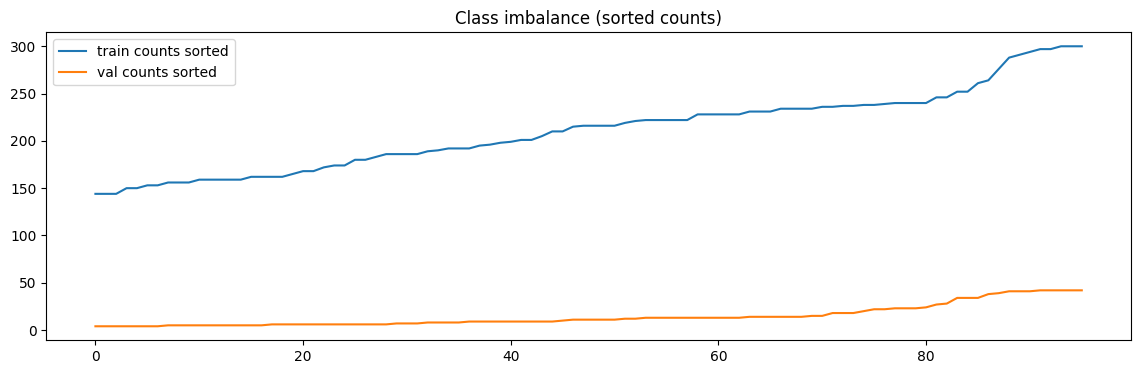

In [9]:
plt.figure(figsize=(14,4))
plt.plot(sorted(train_vals), label="train counts sorted")
plt.plot(sorted(val_vals), label="val counts sorted")
plt.legend()
plt.title("Class imbalance (sorted counts)")
plt.show()

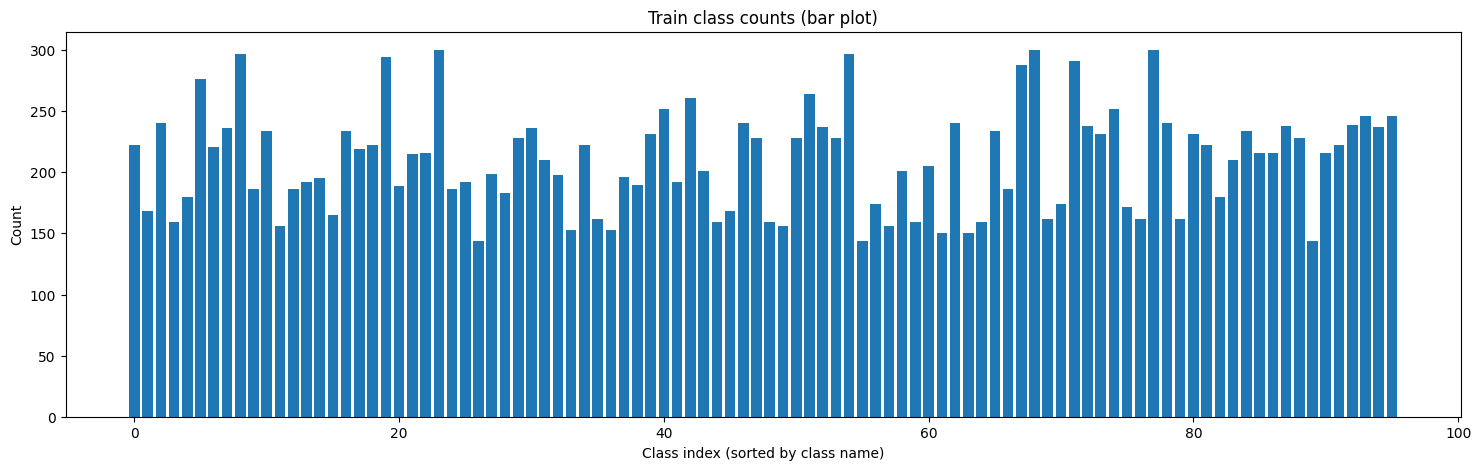

In [10]:
plt.figure(figsize=(18, 5))
plt.bar(range(len(classes)), train_vals)
plt.title("Train class counts (bar plot)")
plt.xlabel("Class index (sorted by class name)")
plt.ylabel("Count")
plt.show()

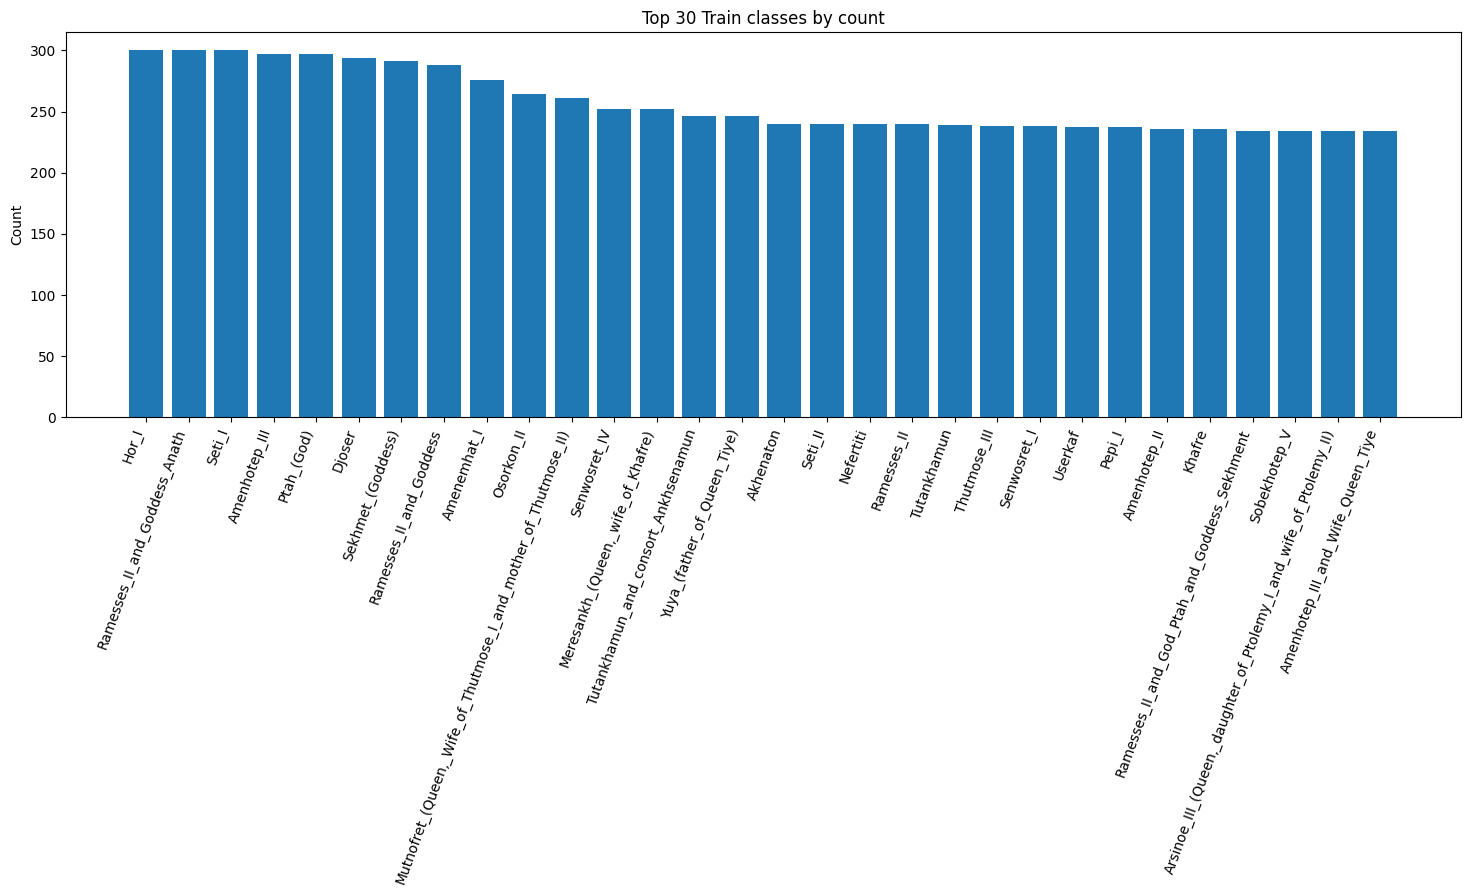

In [11]:
# plot top-30 most frequent
top_k = 30
sorted_idx = np.argsort(-train_vals)[:top_k]
plt.figure(figsize=(18, 5))
plt.bar([classes[i] for i in sorted_idx], train_vals[sorted_idx])
plt.title(f"Top {top_k} Train classes by count")
plt.xticks(rotation=70, ha="right")
plt.ylabel("Count")
plt.show()

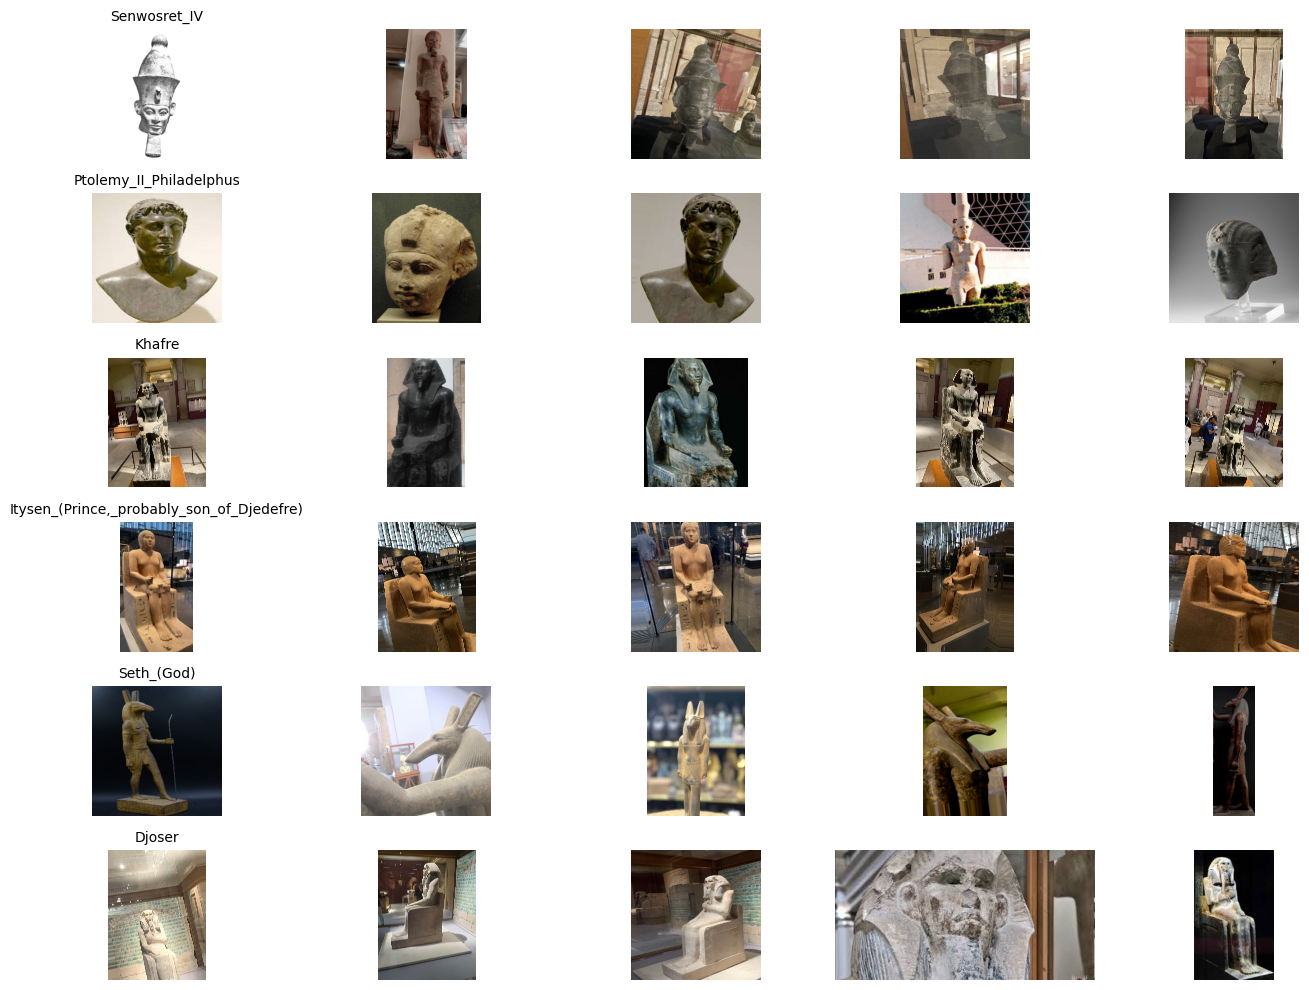

In [12]:
def show_samples_per_class(root: Path, class_names, k=5, rows=6):
    plt.figure(figsize=(14, 10))
    shown = 0
    picked = random.sample(class_names, min(len(class_names), rows))

    for cls in picked:
        imgs = [p for p in (root/cls).iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS]
        if not imgs:
            continue
        for i in range(min(k, len(imgs))):
            img_path = str(random.choice(imgs))
            img = tf.keras.utils.load_img(img_path)
            ax = plt.subplot(rows, k, shown + 1)
            plt.imshow(img)
            plt.axis("off")
            if i == 0:
                ax.set_title(cls, fontsize=10)
            shown += 1
            if shown >= rows * k:
                break
        if shown >= rows * k:
            break

    plt.tight_layout()
    plt.show()

show_samples_per_class(train_dir, classes, k=5, rows=6)


### Pipeline

In [13]:
IMG_SIZE = 256
BATCH_SIZE = 16
NUM_CLASSES = 96  

AUTOTUNE = tf.data.AUTOTUNE

#### Label Encoding

In [14]:
encoder = LabelEncoder()

train_df["label_enc"] = encoder.fit_transform(train_df["label"])
val_df["label_enc"]   = encoder.transform(val_df["label"])
test_df["label_enc"]  = encoder.transform(test_df["label"])

NUM_CLASSES = len(encoder.classes_)
print("NUM_CLASSES:", NUM_CLASSES)

NUM_CLASSES: 96


#### Class Weights

In [15]:
y_train = train_df["label_enc"].values
classes_int = np.unique(y_train)

cw = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=classes_int,
    y=y_train)

In [16]:
cw

array([0.94829204, 1.2531002 , 0.87717014, 1.3240304 , 1.16956019,
       0.76275664, 0.95258296, 0.89203743, 0.70882435, 1.13183244,
       0.89966168, 1.34949252, 1.13183244, 1.09646267, 1.07959402,
       1.27588384, 0.89966168, 0.96128234, 0.94829204, 0.71605726,
       1.11386684, 0.97916667, 0.97463349, 0.70173611, 1.13183244,
       1.09646267, 1.46195023, 1.05789363, 1.15038707, 0.92333699,
       0.89203743, 1.00248016, 1.06323653, 1.37595316, 0.94829204,
       1.29951132, 1.37595316, 1.07408588, 1.10800439, 0.9113456 ,
       0.83540013, 1.09646267, 0.80659323, 1.04736733, 1.3240304 ,
       1.2531002 , 0.87717014, 0.92333699, 1.3240304 , 1.34949252,
       0.92333699, 0.7974274 , 0.88827356, 0.92333699, 0.70882435,
       1.46195023, 1.20988985, 1.34949252, 1.04736733, 1.3240304 ,
       1.02693089, 1.40347222, 0.87717014, 1.40347222, 1.3240304 ,
       0.89966168, 1.13183244, 0.73097512, 0.70173611, 1.29951132,
       1.20988985, 0.72343929, 0.88454132, 0.9113456 , 0.83540

In [17]:
cw_dict = {int(c): float(w) for c, w in zip(classes_int, cw)}

In [18]:
cw_dict

{0: 0.9482920420420421,
 1: 1.2531001984126984,
 2: 0.8771701388888888,
 3: 1.3240303983228512,
 4: 1.1695601851851851,
 5: 0.7627566425120773,
 6: 0.9525829562594268,
 7: 0.892037429378531,
 8: 0.708824354657688,
 9: 1.1318324372759856,
 10: 0.8996616809116809,
 11: 1.3494925213675213,
 12: 1.1318324372759856,
 13: 1.0964626736111112,
 14: 1.079594017094017,
 15: 1.2758838383838385,
 16: 0.8996616809116809,
 17: 0.9612823439878234,
 18: 0.9482920420420421,
 19: 0.7160572562358276,
 20: 1.1138668430335097,
 21: 0.9791666666666666,
 22: 0.974633487654321,
 23: 0.7017361111111111,
 24: 1.1318324372759856,
 25: 1.0964626736111112,
 26: 1.4619502314814814,
 27: 1.057893634840871,
 28: 1.150387067395264,
 29: 0.9233369883040936,
 30: 0.892037429378531,
 31: 1.0024801587301588,
 32: 1.063236531986532,
 33: 1.3759531590413943,
 34: 0.9482920420420421,
 35: 1.299511316872428,
 36: 1.3759531590413943,
 37: 1.0740858843537415,
 38: 1.1080043859649122,
 39: 0.9113455988455988,
 40: 0.835400132275

In [19]:
cw_vec = np.zeros(NUM_CLASSES, dtype=np.float32)
for c, w in cw_dict.items():
    cw_vec[int(c)] = float(w)

cw_tf = tf.constant(cw_vec, dtype=tf.float32)
print("Example weights:", list(cw_dict.items())[:10])

Example weights: [(0, 0.9482920420420421), (1, 1.2531001984126984), (2, 0.8771701388888888), (3, 1.3240303983228512), (4, 1.1695601851851851), (5, 0.7627566425120773), (6, 0.9525829562594268), (7, 0.892037429378531), (8, 0.708824354657688), (9, 1.1318324372759856)]


I0000 00:00:1770054222.461056      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770054222.467082      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


#### ConvNeXt preprocessing

##### On-the-fly Augmentation

In [20]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08,fill_mode="reflect"),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.08, 0.08, fill_mode="reflect"),
], name="data_aug")

In [21]:
class TFDataset:
    def __init__(self, df, batch_size=BATCH_SIZE, shuffle=True, image_size=IMG_SIZE, augment=False):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.image_size = image_size if isinstance(image_size, int) else image_size[0]
        self.dataset = self._build_dataset()

    def _load_raw(self, path, label):
        img = tf.io.read_file(path)          # path is a tf.string tensor (bytes)
        img = tf.image.decode_jpeg(img, channels=3)   # decode jpg -> uint8 [0..255]
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, (self.image_size, self.image_size), method="bilinear")  #resize
        img = tf.cast(img, tf.float32)  
        label = tf.cast(label, tf.int32)   # keep integer label for now
        return img, label

    def _build_dataset(self):
        paths = self.df["path"].values
        labels = self.df["label_enc"].values.astype(np.int32)

        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        ds = ds.map(self._load_raw, num_parallel_calls=AUTOTUNE)

        if self.shuffle:
            ds = ds.shuffle(buffer_size= min(len(self.df), 5000), reshuffle_each_iteration=True)

        if self.augment:
            ds = ds.map(lambda x, y: (data_aug(x, training=True), y),num_parallel_calls=AUTOTUNE)

        ds = ds.batch(self.batch_size)
        
        return ds

    def __iter__(self):
        return iter(self.dataset)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))


##### MixUp

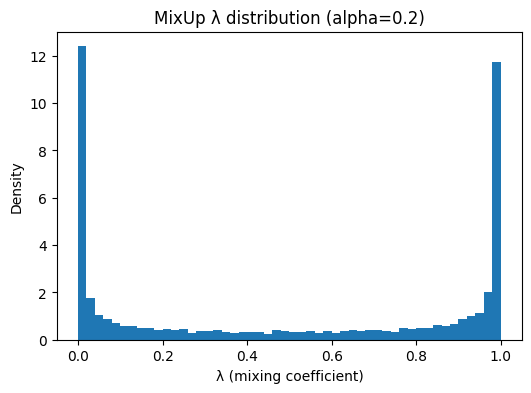

In [22]:
#  λ distribution
# plot to justify MixUp hyperparameter choice (α).
alpha = 0.2
N = 10000

lam = np.random.beta(alpha, alpha, N)

plt.figure(figsize=(6,4))
plt.hist(lam, bins=50, density=True)
plt.xlabel("λ (mixing coefficient)")
plt.ylabel("Density")
plt.title(f"MixUp λ distribution (alpha={alpha})")
plt.show()

In [23]:
MIXUP_ALPHA = 0.2

def _sample_beta(alpha, shape):
    g1 = tf.random.gamma(shape, alpha)
    g2 = tf.random.gamma(shape, alpha)
    return g1 / (g1 + g2)

def _to_onehot(labels_int):
    return tf.one_hot(labels_int, NUM_CLASSES, dtype=tf.float32)

def _sample_weight_from_onehot(y_onehot):
    # expected weight per sample: sum_j y_j * w_j
    return tf.reduce_sum(y_onehot * cw_tf[None, :], axis=1)  # (B,)


In [24]:
def mixup_batch(images, labels_int):
    B = tf.shape(images)[0]
    y1 = _to_onehot(labels_int)

    idx = tf.random.shuffle(tf.range(B))
    x2 = tf.gather(images, idx)
    y2 = tf.gather(y1, idx)

    lam = _sample_beta(MIXUP_ALPHA, [B])
    lam_x = tf.reshape(lam, [B, 1, 1, 1])
    lam_y = tf.reshape(lam, [B, 1])

    x = images * lam_x + x2 * (1.0 - lam_x)
    y = y1 * lam_y + y2 * (1.0 - lam_y)

    sw = _sample_weight_from_onehot(y)
    return x, y, sw

In [25]:
def plain_batch_train(images, labels_int):
    y = _to_onehot(labels_int)
    sw = _sample_weight_from_onehot(y)
    return images, y, sw

def plain_batch_eval(images, labels_int):
    y = _to_onehot(labels_int)
    sw = tf.ones([tf.shape(images)[0]], tf.float32)
    return images, y, sw

def maybe_mixup(images, labels_int, mixup_prob):
    mixup_prob = tf.cast(mixup_prob, tf.float32)
    do = tf.random.uniform([]) < mixup_prob
    return tf.cond(
        do,
        lambda: mixup_batch(images, labels_int),
        lambda: plain_batch_train(images, labels_int),
    )


In [ ]:
def convnext_normalize(x, y, sw):
    x = preprocess_input(x)
    return x, y, sw


In [27]:
def apply_aug(x, y):
    return data_aug(x, training=True), y

In [ ]:
base_ds = TFDataset(train_df, augment=False, shuffle=True).dataset

# Phase A: NO MixUp (prob = 0)
train_ds = (
    base_ds
    .map(apply_aug, num_parallel_calls=AUTOTUNE)
    .map(plain_batch_train, num_parallel_calls=AUTOTUNE)
    .map(convnext_normalize, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)  
)

# Phase B: MixUp ON (light MIXUP)
MIXUP_PROB  = 0.25
train_ds_mix = (
    base_ds
    .map(apply_aug, num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: maybe_mixup(x, y, MIXUP_PROB), num_parallel_calls=AUTOTUNE)
    .map(convnext_normalize, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)


# Val/Test: no MixUp, no class weights
val_ds = (
    TFDataset(val_df, augment=False, shuffle=False).dataset
    .map(plain_batch_eval, num_parallel_calls=AUTOTUNE)
    .map(convnext_normalize, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    TFDataset(test_df, augment=False, shuffle=False).dataset
    .map(plain_batch_eval, num_parallel_calls=AUTOTUNE)
    .map(convnext_normalize, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)


In [ ]:
# Phase A batch
x, y, sw = next(iter(train_ds.take(1)))
print("train_ds:", x.shape, y.shape, sw.shape, y.dtype, sw.dtype)

# Phase B batch
x2, y2, sw2 = next(iter(train_ds_mix.take(1)))
print("train_ds_mix:", x2.shape, y2.shape, sw2.shape, y2.dtype, sw2.dtype)

# Validation batch
xv, yv, swv = next(iter(val_ds.take(1)))
print("val_ds:", xv.shape, yv.shape, swv.shape, yv.dtype, swv.dtype)

'\n#Sanity Check\n\n# Phase A batch\nx, y, sw = next(iter(train_ds.take(1)))\nprint("train_ds:", x.shape, y.shape, sw.shape, y.dtype, sw.dtype)\n\n# Phase B batch\nx2, y2, sw2 = next(iter(train_ds_mix.take(1)))\nprint("train_ds_mix:", x2.shape, y2.shape, sw2.shape, y2.dtype, sw2.dtype)\n\n# Validation batch\nxv, yv, swv = next(iter(val_ds.take(1)))\nprint("val_ds:", xv.shape, yv.shape, swv.shape, yv.dtype, swv.dtype)\n'

#### Model

In [30]:
base = tf.keras.applications.ConvNeXtSmall(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling=None
)

198551472/198551472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [31]:
def build_model(base,img_size=IMG_SIZE):
    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = base(inputs)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation="gelu")(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = Model(inputs, outputs)
    
    return model


#### Training 

In [32]:
# End-to-end training from the start (one-stage backbone training)
base.trainable = True
model = build_model(base, IMG_SIZE)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_small (Functional)     │ (None, 8, 8, 768)      │    49,454,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │        49,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,897,664 (190.34 MB)

 Trainable params: 49,897,664 (190.34 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
EPOCHS_TOTAL = 25
EPOCHS_NO_MIXUP = 15

In [34]:
print(train_ds.element_spec)
print(val_ds.element_spec)
print(test_ds.element_spec)


(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))
(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))
(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))


##### Phase 1 (no mixup, small lr)

In [35]:
ckpt = ModelCheckpoint(
    "convnext_small_best.keras",
    monitor="val_categorical_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

early = EarlyStopping(
    monitor="val_categorical_accuracy",
    patience=6,
    mode="max",
    restore_best_weights=True,
    verbose=1,
)

In [ ]:
# to stabilize training before fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=3e-5, weight_decay=1e-4), 
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.0),
    metrics=["categorical_accuracy"]
)

history1 = model.fit(
    train_ds,                   
    validation_data=val_ds,
    epochs=EPOCHS_NO_MIXUP,
    callbacks=[ckpt, early],
    verbose=1
)


Epoch 1/15


I0000 00:00:1770054393.797312     139 service.cc:152] XLA service 0x797148005070 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770054393.797362     139 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770054393.797368     139 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770054404.897091     139 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-02 17:46:50.923680: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-02 17:46:51.059789: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1770054434.228930     139 device_co

1263/1264 ━━━━━━━━━━━━━━━━━━━━ 0s 941ms/step - categorical_accuracy: 0.4836 - loss: 2.4557

2026-02-02 18:07:13.869784: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-02 18:07:14.005943: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1264/1264 ━━━━━━━━━━━━━━━━━━━━ 0s 965ms/step - categorical_accuracy: 0.4838 - loss: 2.4551

2026-02-02 18:08:21.955278: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-02 18:08:22.091144: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_categorical_accuracy improved from -inf to 0.71971, saving model to convnext_small_best.keras
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 1481s 1s/step - categorical_accuracy: 0.4839 - loss: 2.4544 - val_categorical_accuracy: 0.7197 - val_loss: 1.1573
Epoch 2/15
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 0s 947ms/step - categorical_accuracy: 0.9173 - loss: 0.3546
Epoch 2: val_categorical_accuracy improved from 0.71971 to 0.88315, saving model to convnext_small_best.keras
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 1361s 981ms/step - categorical_accuracy: 0.9173 - loss: 0.3545 - val_categorical_accuracy: 0.8832 - val_loss: 0.4875
Epoch 3/15
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 0s 948ms/step - categorical_accuracy: 0.9755 - loss: 0.1065
Epoch 3: val_categorical_accuracy improved from 0.88315 to 0.92258, saving model to convnext_small_best.keras
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 1364s 982ms/step - categorical_accuracy: 0.9755 - loss: 0.1065 - val_categorical_accuracy: 0.9226 - val_loss: 0.3083
Epoch 4/15
1264/1264 ━━━━━━

In [37]:
model.save("/kaggle/working/11kVersion_ConvNeXtSmall_phaseA_noMixup.keras")

#### Phase B (finetune, mixup)

In [38]:
EPOCHS_PHASEB = EPOCHS_TOTAL - EPOCHS_NO_MIXUP

In [39]:
print("Backbone trainable:", base.trainable)

Backbone trainable: True


In [ ]:
base.trainable = True
for layer in base.layers:
    layer.trainable = True

In [56]:
ckpt2 = ModelCheckpoint(
    "convnext_small_stage2_best.keras",
    monitor="val_categorical_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

In [57]:
# lower LR for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1.5e-5, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.0),
    metrics=["categorical_accuracy"]
)

history2 = model.fit(
    train_ds_mix,
    validation_data=val_ds,
    epochs=EPOCHS_TOTAL,
    initial_epoch=EPOCHS_NO_MIXUP,
    callbacks=[ckpt2, early]
)

Epoch 16/25
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 0s 970ms/step - categorical_accuracy: 0.9852 - loss: 0.2446
Epoch 16: val_categorical_accuracy improved from -inf to 0.96057, saving model to convnext_small_stage2_best.keras
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 1471s 1s/step - categorical_accuracy: 0.9852 - loss: 0.2446 - val_categorical_accuracy: 0.9606 - val_loss: 0.1781
Epoch 17/25
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 0s 948ms/step - categorical_accuracy: 0.9876 - loss: 0.1793
Epoch 17: val_categorical_accuracy improved from 0.96057 to 0.96487, saving model to convnext_small_stage2_best.keras
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 1350s 975ms/step - categorical_accuracy: 0.9876 - loss: 0.1793 - val_categorical_accuracy: 0.9649 - val_loss: 0.1604
Epoch 18/25
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 0s 949ms/step - categorical_accuracy: 0.9885 - loss: 0.1728
Epoch 18: val_categorical_accuracy did not improve from 0.96487
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 1345s 975ms/step - categorical_accuracy: 0.9885 - loss: 0.1728 - val_c

In [58]:
model.save("/kaggle/working/11kVersion_ConvNeXtSmall_phaseB_withMixUp.keras")

### Results 

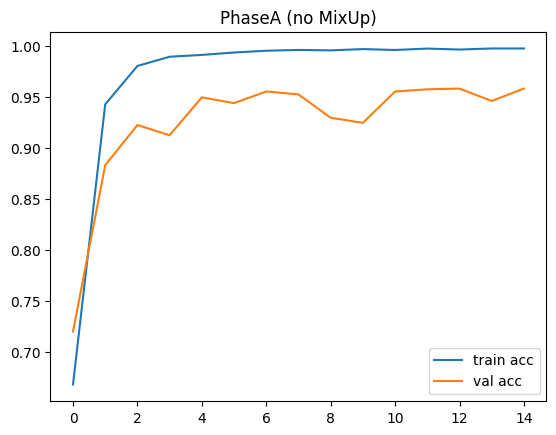

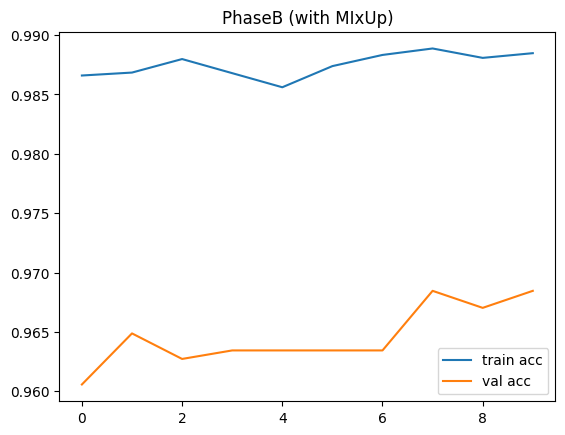

In [59]:
def plot_history(h, title):
    plt.figure()
    plt.plot(h.history["categorical_accuracy"], label="train acc")
    plt.plot(h.history["val_categorical_accuracy"], label="val acc")
    plt.title(title)
    plt.legend()
    plt.show()

plot_history(history1, "PhaseA (no MixUp)")
plot_history(history2, "PhaseB (with MIxUp)")

In [60]:
print(history2.history.keys())

dict_keys(['categorical_accuracy', 'loss', 'val_categorical_accuracy', 'val_loss'])


In [61]:
final_train_loss = history2.history["loss"][-1]
final_val_loss   = history2.history["val_loss"][-1]

final_train_acc = history2.history["categorical_accuracy"][-1]
final_val_acc   = history2.history["val_categorical_accuracy"][-1]

print("Final Train accuracy: ", final_train_acc * 100)
print("Final Train loss: ", final_train_loss)
print("Final Validation accuracy: ", final_val_acc * 100)
print("Final Validation loss: ", final_val_loss)


Final Train accuracy:  98.84710311889648
Final Train loss:  0.15440449118614197
Final Validation accuracy:  96.84587717056274
Final Validation loss:  0.133061021566391


In [62]:
best_epoch = np.argmin(history2.history["val_loss"])
best_val_loss = history2.history["val_loss"][best_epoch]
best_val_acc  = history2.history["val_categorical_accuracy"][best_epoch]

print("Best epoch:", best_epoch + 1)
print("Best val loss:", best_val_loss)
print("Best val acc:", best_val_acc * 100)

Best epoch: 10
Best val loss: 0.133061021566391
Best val acc: 96.84587717056274


In [ ]:
# Evaluate restored best
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)
test_loss, test_acc   = model.evaluate(test_ds, verbose=0)

print("Restored Train acc:", train_acc * 100)
print("Restored Val   acc:", val_acc * 100)
print("Restored Test  acc:", test_acc * 100)


Restored Train acc: 99.8911440372467
Restored Val   acc: 96.84587717056274
Restored Test  acc: 98.16360473632812


#### Confusion matrix + classification report

In [64]:
y_true, y_pred = [], []

for xb, yb, swb in val_ds:   
    preds = model.predict(xb, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1).tolist())

    yb_np = yb.numpy()
    if yb_np.ndim > 1 and yb_np.shape[-1] > 1:
        yb_np = np.argmax(yb_np, axis=1)

    y_true.extend(yb_np.astype(int).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(classes)))
print("Val accuracy:", (y_true == y_pred).mean())
print(classification_report(y_true, y_pred,labels=np.arange(len(classes)),target_names=classes,digits=4))


Val accuracy: 0.9684587813620071
                                                                   precision    recall  f1-score   support

                                                          Achoris     1.0000    1.0000    1.0000        13
                                                         Ahmose_I     1.0000    1.0000    1.0000         5
                                                        Akhenaton     1.0000    1.0000    1.0000        42
                                              Alexander_the_Great     1.0000    0.7778    0.8750         9
                                                        Amasis_II     1.0000    1.0000    1.0000         5
                                                      Amenemhat_I     1.0000    1.0000    1.0000         8
                                                    Amenemhat_III     1.0000    0.8974    0.9459        39
                                                     Amenhotep_II     1.0000    0.9756    0.9877        41
   

#### confusion matrix for most confused classes

In [65]:
support = cm.sum(axis=1)          # number of true samples per class
cm_norm = cm / support[:, None]  # row-normalized confusion rates
confusions = []

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j and cm[i, j] > 0:
            confusions.append((
                cm[i, j],           # count
                cm_norm[i, j],      # rate
                classes[i],         # true
                classes[j]          # predicted
            ))


confusions.sort(reverse=True)       #sorted by count

print("Top confusions:")
for count, rate, true, pred in confusions[:15]:
    print(f"{true} -> {pred} : {count} ({rate*100:.2f}%)")


Top confusions:
Nefertiti -> Userkaf : 3 (7.14%)
Hathor_(Goddess) -> Isis_(Goddess) : 2 (18.18%)
Mentuhotep_II -> Senwosret_I : 2 (8.70%)
Amenhotep_III -> Hatshepsut : 2 (5.88%)
Amenemhat_III -> Thutmose_III : 2 (5.13%)
Isis_(Goddess) -> Sekhmet_(Goddess) : 1 (25.00%)
Sobekemsaf_I -> Ramesses_II : 1 (20.00%)
Shepsekaf -> Ptolemy_II_Philadelphus : 1 (20.00%)
Ptolemy_II_Philadelphus -> Ramesses_II : 1 (20.00%)
Ptolemy_II_Philadelphus -> Arsinoe_II_(Queen,_sister_and_wife_of_Ptolemy_IV) : 1 (20.00%)
Thutmose_IV -> Pepi_I : 1 (16.67%)
Mut_(Goddess) -> Seti_II : 1 (16.67%)
Menkaure_and_his_wife_(likely_Queen_Khamerernebty_II) -> Hatshepsut : 1 (16.67%)
Cleopatra_VII_Philopator -> Sekhmet_(Goddess) : 1 (16.67%)
Osiris_(God) -> Userkaf : 1 (14.29%)


In [66]:
support = cm.sum(axis=1)
cm_norm = cm / support[:, None]

print("All confusions (non-zero):")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j and cm[i, j] > 0:
            print(
                f"{classes[i]} → {classes[j]} : "
                f"{cm[i,j]}/{support[i]} "
                f"({cm_norm[i,j]*100:.2f}%)"
            )


All confusions (non-zero):
Alexander_the_Great → Serapis_(God) : 1/9 (11.11%)
Alexander_the_Great → Thutmose_III : 1/9 (11.11%)
Amenemhat_III → Hatshepsut : 1/39 (2.56%)
Amenemhat_III → Thutmose_III : 2/39 (5.13%)
Amenemhat_III → Thutmose_IV : 1/39 (2.56%)
Amenhotep_II → Thutmose_III : 1/41 (2.44%)
Amenhotep_III → Hatshepsut : 2/34 (5.88%)
Amenhotep_III → Thutmose_III : 1/34 (2.94%)
Amenhotep_III → Userkaf : 1/34 (2.94%)
Amenhotep_III_and_Wife_Queen_Tiye → Ramesses_II : 1/14 (7.14%)
Amenirdis_(Daughter_of_Kashta) → Raneferef : 1/9 (11.11%)
Arsinoe_II_(Queen,_sister_and_wife_of_Ptolemy_IV) → Cleopatra_VII_Philopator : 1/13 (7.69%)
Cleopatra_VII_Philopator → Sekhmet_(Goddess) : 1/6 (16.67%)
Djoser → Ramesses_II_and_Goddesses_Isis_and_Hathor : 1/34 (2.94%)
Hathor_(Goddess) → Isis_(Goddess) : 2/11 (18.18%)
Hathor_(Goddess) → Seth_(God) : 1/11 (9.09%)
Isis_(Goddess) → Sekhmet_(Goddess) : 1/4 (25.00%)
Khafre → Mutnofret_(Queen,_Wife_of_Thutmose_I_and_mother_of_Thutmose_II) : 1/41 (2.44%)
Kha

### Test Inference

In [70]:
y_true, y_pred = [], []

for xb, yb, swb in test_ds:
    preds = model.predict(xb, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

    y_true.extend(np.argmax(yb.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# accuracy
test_acc = (y_true == y_pred).mean()
print(f"Test accuracy: {test_acc:.8f}")

# report
print(classification_report(y_true, y_pred, target_names=encoder.classes_))

cm_test = confusion_matrix(y_true, y_pred)
print("Confusion matrix shape:", cm_test.shape)
print("\nConfusion Matrix:\n", cm_test)

Test accuracy: 0.98163606
                                                                   precision    recall  f1-score   support

                                                          Achoris       1.00      1.00      1.00         6
                                                         Ahmose_I       1.00      1.00      1.00         2
                                                        Akhenaton       1.00      1.00      1.00        18
                                              Alexander_the_Great       1.00      1.00      1.00         4
                                                        Amasis_II       0.67      1.00      0.80         2
                                                      Amenemhat_I       1.00      1.00      1.00         4
                                                    Amenemhat_III       1.00      1.00      1.00        16
                                                     Amenhotep_II       1.00      0.94      0.97        18
          

In [71]:
print(f"Test accuracy: {test_acc*100:.8f}")

Test accuracy: 98.16360601


In [72]:
#Evaluate 
ckpt_path = os.path.join(OUT_DIR, "convnext_small_stage2_best.keras")
model = tf.keras.models.load_model(ckpt_path)

val_loss, val_acc= model.evaluate(val_ds, verbose=1)
print("VAL  loss:", val_loss, "acc:", val_acc)

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print("TEST loss:", test_loss, "acc:", test_acc)


88/88 ━━━━━━━━━━━━━━━━━━━━ 47s 414ms/step - categorical_accuracy: 0.9605 - loss: 0.1567
VAL  loss: 0.14400547742843628 acc: 0.9684587717056274
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 526ms/step - categorical_accuracy: 0.9848 - loss: 0.0817
TEST loss: 0.0914158970117569 acc: 0.9816360473632812


In [52]:
"""
#Evaluate 
OUT_DIR = "/kaggle/working"
ckpt_path = os.path.join(OUT_DIR, "convnext_small_best.keras")
model = tf.keras.models.load_model(ckpt_path)

val_loss, val_acc= model.evaluate(val_ds, verbose=1)
print("VAL  loss:", val_loss, "acc:", val_acc)

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print("TEST loss:", test_loss, "acc:", test_acc)
"""

88/88 ━━━━━━━━━━━━━━━━━━━━ 43s 365ms/step - categorical_accuracy: 0.9481 - loss: 0.2421
VAL  loss: 0.200867161154747 acc: 0.9584229588508606
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 482ms/step - categorical_accuracy: 0.9738 - loss: 0.1121
TEST loss: 0.1399315893650055 acc: 0.9649415612220764


In [73]:
support_test = cm_test.sum(axis=1)
cm_norm_test = cm_test / support_test[:, None]

print("All confusions (non-zero):")
for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        if i != j and cm_test[i, j] > 0:
            print(
                f"{classes[i]} → {classes[j]} : "
                f"{cm_test[i,j]}/{support_test[i]} "
                f"({cm_norm_test[i,j]*100:.2f}%)"
            )


All confusions (non-zero):
Amenhotep_II → Thutmose_III : 1/18 (5.56%)
Amenhotep_III → Userkaf : 1/15 (6.67%)
Isis_(Goddess) → Seti_I : 1/2 (50.00%)
Khafre → Thutmose_III : 1/18 (5.56%)
Meresankh_(Queen,_wife_of_Khafre) → Thutmose_III : 1/3 (33.33%)
Ramesses_II → Sekhmet_(Goddess) : 1/18 (5.56%)
Ramesses_II → Seti_II : 1/18 (5.56%)
Senwosret_I → Thutmose_III : 1/18 (5.56%)
Sobekhotep_V → Sobekhotep_IV : 1/6 (16.67%)
Thutmose_III → Amasis_II : 1/18 (5.56%)
Thutmose_III → Senwosret_I : 1/18 (5.56%)


In [74]:
#sorted by rate
support_test = cm_test.sum(axis=1)
cm_norm_test = cm_test / support_test[:, None]
all_confusions_test =[]

print("All confusions (non-zero):")
for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        if i != j and cm_test[i, j] > 0:
           all_confusions_test.append((cm_norm_test[i,j], cm_test[i,j], classes[i], classes[j]))

all_confusions_test.sort(reverse=True) # sorts by rate first

print("Top confusions by RATE:")
for rate, count, true, pred in all_confusions_test:
    print(f"{true} → {pred} :  {count}/{support_test[classes.index(true)]} ({rate*100:.2f}%)")

All confusions (non-zero):
Top confusions by RATE:
Isis_(Goddess) → Seti_I :  1/2 (50.00%)
Meresankh_(Queen,_wife_of_Khafre) → Thutmose_III :  1/3 (33.33%)
Sobekhotep_V → Sobekhotep_IV :  1/6 (16.67%)
Amenhotep_III → Userkaf :  1/15 (6.67%)
Thutmose_III → Senwosret_I :  1/18 (5.56%)
Thutmose_III → Amasis_II :  1/18 (5.56%)
Senwosret_I → Thutmose_III :  1/18 (5.56%)
Ramesses_II → Seti_II :  1/18 (5.56%)
Ramesses_II → Sekhmet_(Goddess) :  1/18 (5.56%)
Khafre → Thutmose_III :  1/18 (5.56%)
Amenhotep_II → Thutmose_III :  1/18 (5.56%)


### Save Outputs

In [ ]:
"""
# Save final model
model.save("efficientb0_aug_150version_2stagetrain.keras")

with open("/kaggle/working/label_encoder_efficientnetb0_aug_150version_2StageTrain.pkl", "wb") as f:
    pickle.dump(encoder, f)
    """

In [55]:
with open("/kaggle/working/label_encoder_convnextSmall_aug_11kversion_2PhaseTrain.pkl", "wb") as f:
    pickle.dump(encoder, f)